# MuSiQue exploratory data analysis

## 1. Dataset contract and integrity audit

This section establishes what data was actually loaded before any substantive EDA or model runs. It checks the top-level schema, split sizes, identifier structure, nested paragraph and decomposition records, and the references connecting decomposition steps to supporting paragraphs.

The audit is intentionally limited to the MuSiQue data itself. It does not use the outdated project proposal in the repository. Its output is a descriptive validation report, not a modification of the source data.

In [11]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")


def find_repo_root(start: Path) -> Path:
    """Find the repository root from either the repo or notebook directory."""
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "environment.yml").exists() and (candidate / "Code" / "notebooks").exists():
            return candidate
    raise FileNotFoundError("Could not locate the repository root from the current working directory.")


REPO_ROOT = find_repo_root(Path.cwd())
DATA_DIR = REPO_ROOT / "data" / "MuSiQue" / "clean"
FIG_DIR = REPO_ROOT / "Code" / "notebooks" / "figs"
FIG_DIR.mkdir(parents=True, exist_ok=True)

DATA_FILES = {
    "train": DATA_DIR / "train.json",
    "validation": DATA_DIR / "validation.json",
}
EXPECTED_COLUMNS = (
    "id",
    "paragraphs",
    "question",
    "question_decomposition",
    "answer",
    "answer_aliases",
    "answerable",
)

### Data source and loading behavior

The notebook reuses the paths produced by `Code/scripts/get_MuSiQue_dataset.py`. That script loads `dgslibisey/MuSiQue` and writes newline-delimited JSON to `data/MuSiQue/clean/train.json` and `validation.json`. Despite the `.json` suffix, each file contains one JSON record per line, so `pandas.read_json(..., lines=True)` is required.

If the files are missing, run the download script from the repository root before continuing. The explicit missing-file error below prevents the notebook from silently analyzing partial or unintended data.

In [12]:
missing_files = [path for path in DATA_FILES.values() if not path.exists()]
if missing_files:
    missing_display = "\n".join(f"- {path}" for path in missing_files)
    raise FileNotFoundError(
        "Required MuSiQue files are missing:\n"
        f"{missing_display}\n"
        "Run: python Code/scripts/get_MuSiQue_dataset.py"
    )

splits = {
    split_name: pd.read_json(path, lines=True)
    for split_name, path in DATA_FILES.items()
}

dataset_inventory = pd.DataFrame(
    [
        {
            "split": split_name,
            "rows": len(frame),
            "columns": len(frame.columns),
            "unique_ids": frame["id"].nunique(dropna=False),
            "answerable_true": int(frame["answerable"].eq(True).sum()),
            "rows_with_20_paragraphs": int(
                frame["paragraphs"].map(lambda value: isinstance(value, list) and len(value) == 20).sum()
            ),
        }
        for split_name, frame in splits.items()
    ]
).set_index("split")

display(dataset_inventory)
display(pd.DataFrame({name: frame.dtypes.astype(str) for name, frame in splits.items()}))

,rows,columns,unique_ids,answerable_true,rows_with_20_paragraphs
split,,,,,
train,19938,7,19938,19938,19917
validation,2417,7,2417,2417,2401


,train,validation
id,str,str
paragraphs,object,object
question,str,str
question_decomposition,object,object
answer,str,str
answer_aliases,object,object
answerable,bool,bool


### Integrity rules

The audit checks the following contracts for every split:

1. The seven expected top-level columns are present, with no unexpected columns or missing values.
2. IDs are unique and follow MuSiQue's encoded hop/graph pattern, such as `2hop__...`, `3hop1__...`, or `4hop3__...`.
3. `paragraphs` and `question_decomposition` are lists of records with the required nested keys.
4. The encoded hop count equals the number of decomposition steps, and component IDs in the composite ID match the ordered decomposition IDs.
5. Every `paragraph_support_idx` is in range, points to the paragraph with that same index, and points to a paragraph marked as supporting. The complete set of referenced paragraphs must equal the marked support set.
6. The final answer equals the last decomposition answer after whitespace and case normalization.
7. All records are answerable, which confirms that the current source is MuSiQue-Ans rather than MuSiQue-Full.

Duplicate normalized question text and records containing other than 20 paragraphs are warnings rather than failures. They deserve inspection, but do not necessarily indicate broken records. All structural and referential violations are failures.

In [13]:
ID_PATTERN = re.compile(
    r"^(?P<hops>[2-4])hop(?P<shape>[1-3]?)__(?P<components>\d+(?:_\d+)*)$"
)
PARAGRAPH_KEYS = {"idx", "title", "paragraph_text", "is_supporting"}
DECOMPOSITION_KEYS = {"id", "question", "answer", "paragraph_support_idx"}


def normalize_text(value: object) -> str:
    return str(value).strip().casefold()


def audit_split(frame: pd.DataFrame) -> dict[str, int]:
    missing_columns = set(EXPECTED_COLUMNS) - set(frame.columns)
    unexpected_columns = set(frame.columns) - set(EXPECTED_COLUMNS)
    counts = {
        "schema_column_violations": len(missing_columns) + len(unexpected_columns),
        "missing_top_level_values": int(frame.isna().sum().sum()),
        "duplicate_ids": 0,
        "duplicate_normalized_questions": 0,
        "malformed_ids": 0,
        "invalid_paragraph_records": 0,
        "paragraph_index_violations": 0,
        "invalid_decomposition_records": 0,
        "hop_decomposition_mismatches": 0,
        "component_id_mismatches": 0,
        "support_reference_violations": 0,
        "support_set_mismatches": 0,
        "final_answer_mismatches": 0,
        "non_answerable_rows": 0,
        "non_20_paragraph_rows": 0,
    }
    if missing_columns:
        return counts

    counts["duplicate_ids"] = int(frame["id"].duplicated().sum())
    counts["duplicate_normalized_questions"] = int(
        frame["question"].map(normalize_text).duplicated().sum()
    )
    counts["non_answerable_rows"] = int(frame["answerable"].ne(True).sum())

    for row in frame.itertuples(index=False):
        identifier_match = ID_PATTERN.fullmatch(str(row.id))
        if identifier_match is None:
            counts["malformed_ids"] += 1

        paragraphs = row.paragraphs
        decomposition = row.question_decomposition

        paragraphs_valid = isinstance(paragraphs, list) and all(
            isinstance(paragraph, dict) and PARAGRAPH_KEYS.issubset(paragraph)
            for paragraph in paragraphs
        )
        if not paragraphs_valid:
            counts["invalid_paragraph_records"] += 1
            continue

        if [paragraph["idx"] for paragraph in paragraphs] != list(range(len(paragraphs))):
            counts["paragraph_index_violations"] += 1

        decomposition_valid = isinstance(decomposition, list) and all(
            isinstance(step, dict) and DECOMPOSITION_KEYS.issubset(step)
            for step in decomposition
        )
        if not decomposition_valid:
            counts["invalid_decomposition_records"] += 1
            continue

        if identifier_match is not None:
            encoded_hops = int(identifier_match.group("hops"))
            encoded_components = identifier_match.group("components").split("_")
            observed_components = [str(step["id"]) for step in decomposition]
            if encoded_hops != len(decomposition):
                counts["hop_decomposition_mismatches"] += 1
            if encoded_components != observed_components:
                counts["component_id_mismatches"] += 1

        referenced_support = []
        support_reference_is_invalid = False
        for step in decomposition:
            support_idx = step["paragraph_support_idx"]
            reference_is_valid = (
                isinstance(support_idx, int)
                and 0 <= support_idx < len(paragraphs)
                and paragraphs[support_idx]["idx"] == support_idx
            )
            if not reference_is_valid:
                support_reference_is_invalid = True
                continue
            referenced_support.append(support_idx)
            if paragraphs[support_idx]["is_supporting"] is not True:
                support_reference_is_invalid = True

        if support_reference_is_invalid:
            counts["support_reference_violations"] += 1

        marked_support = {
            paragraph["idx"]
            for paragraph in paragraphs
            if paragraph["is_supporting"] is True
        }
        if set(referenced_support) != marked_support:
            counts["support_set_mismatches"] += 1

        if decomposition and normalize_text(row.answer) != normalize_text(decomposition[-1]["answer"]):
            counts["final_answer_mismatches"] += 1

        if len(paragraphs) != 20:
            counts["non_20_paragraph_rows"] += 1

    return counts


audit_counts = {split_name: audit_split(frame) for split_name, frame in splits.items()}

CHECK_LABELS = {
    "schema_column_violations": "Missing or unexpected columns",
    "missing_top_level_values": "Missing top-level values",
    "duplicate_ids": "Duplicate IDs",
    "duplicate_normalized_questions": "Duplicate normalized questions",
    "malformed_ids": "Malformed composite IDs",
    "invalid_paragraph_records": "Invalid paragraph records",
    "paragraph_index_violations": "Non-sequential paragraph indexes",
    "invalid_decomposition_records": "Invalid decomposition records",
    "hop_decomposition_mismatches": "Hop/decomposition mismatches",
    "component_id_mismatches": "Composite/decomposition ID mismatches",
    "support_reference_violations": "Invalid or unmarked support references",
    "support_set_mismatches": "Referenced/marked support-set mismatches",
    "final_answer_mismatches": "Final/decomposition answer mismatches",
    "non_answerable_rows": "Non-answerable rows",
    "non_20_paragraph_rows": "Rows without 20 paragraphs",
}
WARNING_CHECKS = {"duplicate_normalized_questions", "non_20_paragraph_rows"}

audit_table = pd.DataFrame(
    {
        "check": [CHECK_LABELS[key] for key in CHECK_LABELS],
        **{
            split_name: [counts[key] for key in CHECK_LABELS]
            for split_name, counts in audit_counts.items()
        },
    },
    index=list(CHECK_LABELS),
)

def check_status(check_name: str) -> str:
    has_findings = any(audit_counts[split_name][check_name] > 0 for split_name in splits)
    if not has_findings:
        return "PASS"
    return "WARN" if check_name in WARNING_CHECKS else "FAIL"


audit_table["status"] = [check_status(check_name) for check_name in audit_table.index]
audit_table = audit_table.reset_index(drop=True)
display(audit_table)

,check,train,validation,status
0,Missing or unexpected columns,0,0,PASS
1,Missing top-level values,0,0,PASS
2,Duplicate IDs,0,0,PASS
3,Duplicate normalized questions,42,6,WARN
4,Malformed composite IDs,0,0,PASS
5,Invalid paragraph records,0,0,PASS
6,Non-sequential paragraph indexes,0,0,PASS
7,Invalid decomposition records,0,0,PASS
8,Hop/decomposition mismatches,0,0,PASS
9,Composite/decomposition ID mismatches,0,0,PASS


### Saved audit artifact

The next cell turns the inventory and validation results into a compact report table. Following the project artifact convention, the same descriptive stem is exported twice to `Code/notebooks/figs`: once as PDF and once as SVG. Both files are derived from the same Matplotlib figure, so their content remains synchronized.

Status meanings:

- **PASS:** no instances violated the rule.
- **WARN:** non-blocking cases were found and should be characterized later.
- **FAIL:** a structural or referential contract was violated and should be resolved before downstream EDA.

,saved_artifact
0,Code/notebooks/figs/dataset_schema_and_integri...
1,Code/notebooks/figs/dataset_schema_and_integri...


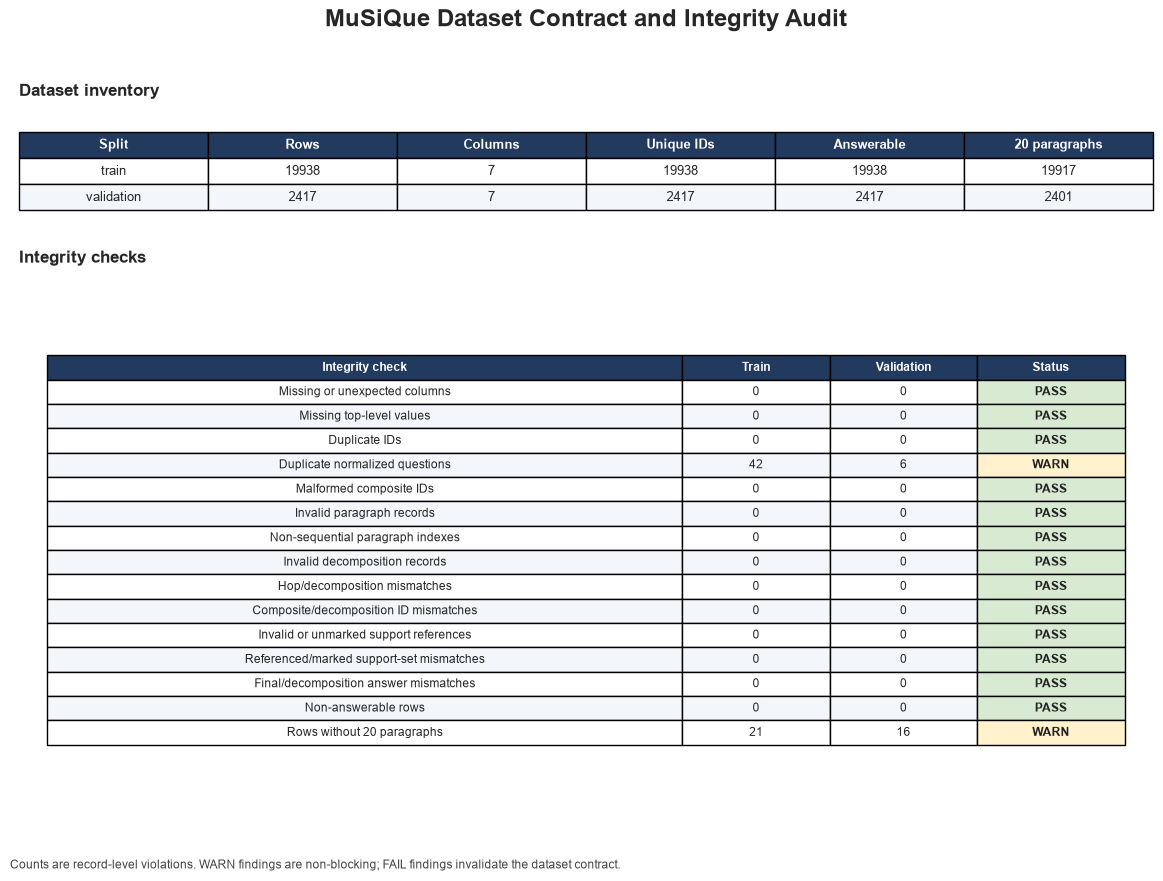

In [14]:
inventory_for_figure = dataset_inventory.reset_index().copy()
inventory_for_figure.columns = [
    "Split",
    "Rows",
    "Columns",
    "Unique IDs",
    "Answerable",
    "20 paragraphs",
]
audit_for_figure = audit_table.rename(
    columns={"check": "Integrity check", "train": "Train", "validation": "Validation", "status": "Status"}
)

fig, axes = plt.subplots(
    2,
    1,
    figsize=(12, 9),
    gridspec_kw={"height_ratios": [1.0, 4.3]},
)
fig.patch.set_facecolor("white")
fig.suptitle("MuSiQue Dataset Contract and Integrity Audit", fontsize=17, fontweight="bold", y=0.98)

for axis in axes:
    axis.axis("off")

axes[0].set_title("Dataset inventory", loc="left", fontsize=12, fontweight="bold", pad=8)
inventory_artist = axes[0].table(
    cellText=inventory_for_figure.values,
    colLabels=inventory_for_figure.columns,
    cellLoc="center",
    colLoc="center",
    loc="center",
)
inventory_artist.auto_set_font_size(False)
inventory_artist.set_fontsize(9)
inventory_artist.scale(1, 1.45)

axes[1].set_title("Integrity checks", loc="left", fontsize=12, fontweight="bold", pad=8)
audit_artist = axes[1].table(
    cellText=audit_for_figure.values,
    colLabels=audit_for_figure.columns,
    cellLoc="center",
    colLoc="center",
    colWidths=[0.56, 0.13, 0.13, 0.13],
    loc="center",
)
audit_artist.auto_set_font_size(False)
audit_artist.set_fontsize(8.5)
audit_artist.scale(1, 1.35)

for table_artist in (inventory_artist, audit_artist):
    for (row_index, _), cell in table_artist.get_celld().items():
        if row_index == 0:
            cell.set_facecolor("#223A5E")
            cell.set_text_props(color="white", fontweight="bold")
        elif row_index % 2 == 0:
            cell.set_facecolor("#F3F6FA")

status_colors = {"PASS": "#D9EAD3", "WARN": "#FFF2CC", "FAIL": "#F4CCCC"}
status_column = list(audit_for_figure.columns).index("Status")
for row_index, status in enumerate(audit_for_figure["Status"], start=1):
    status_cell = audit_artist[(row_index, status_column)]
    status_cell.set_facecolor(status_colors[status])
    status_cell.set_text_props(fontweight="bold", color="#222222")

fig.text(
    0.02,
    0.025,
    "Counts are record-level violations. WARN findings are non-blocking; FAIL findings invalidate the dataset contract.",
    fontsize=8.5,
    color="#444444",
)
fig.tight_layout(rect=[0.015, 0.055, 0.985, 0.955])

artifact_stem = "dataset_schema_and_integrity_audit"
artifact_paths = []
for file_format in ("pdf", "svg"):
    artifact_path = FIG_DIR / f"{artifact_stem}.{file_format}"
    fig.savefig(artifact_path, format=file_format, bbox_inches="tight")
    artifact_paths.append(artifact_path)

display(pd.DataFrame({"saved_artifact": [str(path.relative_to(REPO_ROOT)) for path in artifact_paths]}))
plt.show()

### Interpretation

Structural failures should stop downstream work because they can corrupt hop labels, support annotations, or final-answer labels. Warnings are retained as explicit counts so later EDA can investigate whether repeated question wording or variable paragraph counts create experimental confounds.

Once this contract passes, the next EDA section can characterize hop-count and reasoning-graph coverage without repeatedly revalidating the nested data model.

## 2. Experimental coverage

This section measures how MuSiQue's reasoning structures are represented in each split. The purpose is to identify imbalances before selecting questions for expensive solver, critic, activation-caching, SAE, and causal-intervention runs. A random subset that mirrors the full dataset may contain very few examples from the rare graph shapes, which would make comparisons across reasoning structures unreliable.

The analysis reuses the validated `splits`, `ID_PATTERN`, `normalize_text`, and `FIG_DIR` objects created in section 1. It does not reload or modify the source records.

### Coverage and reuse definitions

MuSiQue encodes its reasoning structure at the start of each composite ID. `2hop` is the single two-hop graph shape; `3hop1`, `3hop2`, `4hop1`, `4hop2`, and `4hop3` distinguish the five three-hop and four-hop shapes. Counts and percentages are calculated within each split so train and validation remain directly comparable despite their different sizes.

The reuse profile measures final-answer text, supporting-paragraph titles, and component-question IDs. For each feature, the repeated-occurrence rate is `(total occurrences - unique values) / total occurrences`. This is not treated as duplication or leakage: MuSiQue deliberately composes multihop questions from reusable single-hop material. Instead, the metric shows why later experimental sampling and model evaluation may need grouping or stratification. Cross-split overlap is intentionally deferred to the dedicated leakage audit.

In [15]:
GRAPH_ORDER = ("2hop", "3hop1", "3hop2", "4hop1", "4hop2", "4hop3")
GRAPH_LABELS = {
    "2hop": "2-hop",
    "3hop1": "3-hop shape 1",
    "3hop2": "3-hop shape 2",
    "4hop1": "4-hop shape 1",
    "4hop2": "4-hop shape 2",
    "4hop3": "4-hop shape 3",
}
HOP_ORDER = (2, 3, 4)

coverage_records = []
for split_name, frame in splits.items():
    graph_codes = frame["id"].str.extract(r"^([2-4]hop[1-3]?)__", expand=False)
    graph_counts = graph_codes.value_counts().reindex(GRAPH_ORDER, fill_value=0)
    for graph_code, count in graph_counts.items():
        coverage_records.append(
            {
                "split": split_name,
                "graph_code": graph_code,
                "graph_shape": GRAPH_LABELS[graph_code],
                "hop_count": int(graph_code[0]),
                "count": int(count),
                "split_share_pct": 100 * int(count) / len(frame),
            }
        )

graph_coverage = pd.DataFrame(coverage_records)
hop_coverage = (
    graph_coverage.groupby(["split", "hop_count"], as_index=False)["count"]
    .sum()
    .assign(
        split_share_pct=lambda table: table["count"]
        / table.groupby("split")["count"].transform("sum")
        * 100
    )
)


def summarize_reuse(values: list[str]) -> dict[str, float | int]:
    value_counts = pd.Series(values, dtype="string").value_counts()
    total_occurrences = int(value_counts.sum())
    unique_values = int(len(value_counts))
    return {
        "total_occurrences": total_occurrences,
        "unique_values": unique_values,
        "values_used_more_than_once": int(value_counts.gt(1).sum()),
        "repeated_occurrences": total_occurrences - unique_values,
        "repeated_occurrence_pct": 100 * (total_occurrences - unique_values) / total_occurrences,
        "maximum_occurrences_for_one_value": int(value_counts.max()),
    }


reuse_records = []
for split_name, frame in splits.items():
    feature_values = {
        "Final answers": [normalize_text(answer) for answer in frame["answer"]],
        "Supporting titles": [
            normalize_text(paragraph["title"])
            for paragraphs in frame["paragraphs"]
            for paragraph in paragraphs
            if paragraph["is_supporting"] is True
        ],
        "Component question IDs": [
            str(step["id"])
            for decomposition in frame["question_decomposition"]
            for step in decomposition
        ],
    }
    for feature_name, values in feature_values.items():
        reuse_records.append(
            {"split": split_name, "feature": feature_name, **summarize_reuse(values)}
        )

reuse_profile = pd.DataFrame(reuse_records)

rarest_strata = (
    graph_coverage.sort_values(["split", "count"])
    .groupby("split", as_index=False)
    .first()[["split", "graph_shape", "count", "split_share_pct"]]
)

display(
    graph_coverage[["split", "graph_shape", "count", "split_share_pct"]]
    .assign(split_share_pct=lambda table: table["split_share_pct"].round(2))
    .rename(columns={"split_share_pct": "split_share_pct (%)"})
)
display(
    reuse_profile.assign(
        repeated_occurrence_pct=lambda table: table["repeated_occurrence_pct"].round(1)
    )
)
display(
    rarest_strata.assign(split_share_pct=lambda table: table["split_share_pct"].round(2))
    .rename(columns={"split_share_pct": "split_share_pct (%)"})
)

,split,graph_shape,count,split_share_pct (%)
0,train,2-hop,14376,72.10
1,train,3-hop shape 1,3737,18.74
2,train,3-hop shape 2,650,3.26
3,train,4-hop shape 1,648,3.25
4,train,4-hop shape 2,127,0.64
5,train,4-hop shape 3,400,2.01
6,validation,2-hop,1252,51.80
7,validation,3-hop shape 1,568,23.50
8,validation,3-hop shape 2,192,7.94
9,validation,4-hop shape 1,246,10.18


,split,feature,total_occurrences,unique_values,values_used_more_than_once,repeated_occurrences,repeated_occurrence_pct,maximum_occurrences_for_one_value
0,train,Final answers,19938,2057,1674,17881,89.7,113
1,train,Supporting titles,46613,12304,5233,34309,73.6,249
2,train,Component question IDs,46613,14589,6043,32024,68.7,50
3,validation,Final answers,2417,738,383,1679,69.5,34
4,validation,Supporting titles,6404,2328,880,4076,63.6,56
5,validation,Component question IDs,6404,2768,915,3636,56.8,48


,split,graph_shape,count,split_share_pct (%)
0,train,4-hop shape 2,127,0.64
1,validation,4-hop shape 2,64,2.65


### Saved coverage artifact

The report below combines four complementary views:

- Hop percentages show the broad difficulty mix in each split.
- Graph-shape counts use a logarithmic axis so both dominant and rare strata remain visible.
- The coverage table supplies exact counts and within-split percentages.
- The reuse table shows how often answers, supporting titles, and component questions recur.

The logarithmic axis affects only the graph-shape count chart; the annotated labels and all tables retain the original counts. The same report is saved as PDF and SVG under the descriptive stem `split_hop_graph_distribution`.

,saved_artifact
0,Code/notebooks/figs/split_hop_graph_distributi...
1,Code/notebooks/figs/split_hop_graph_distributi...


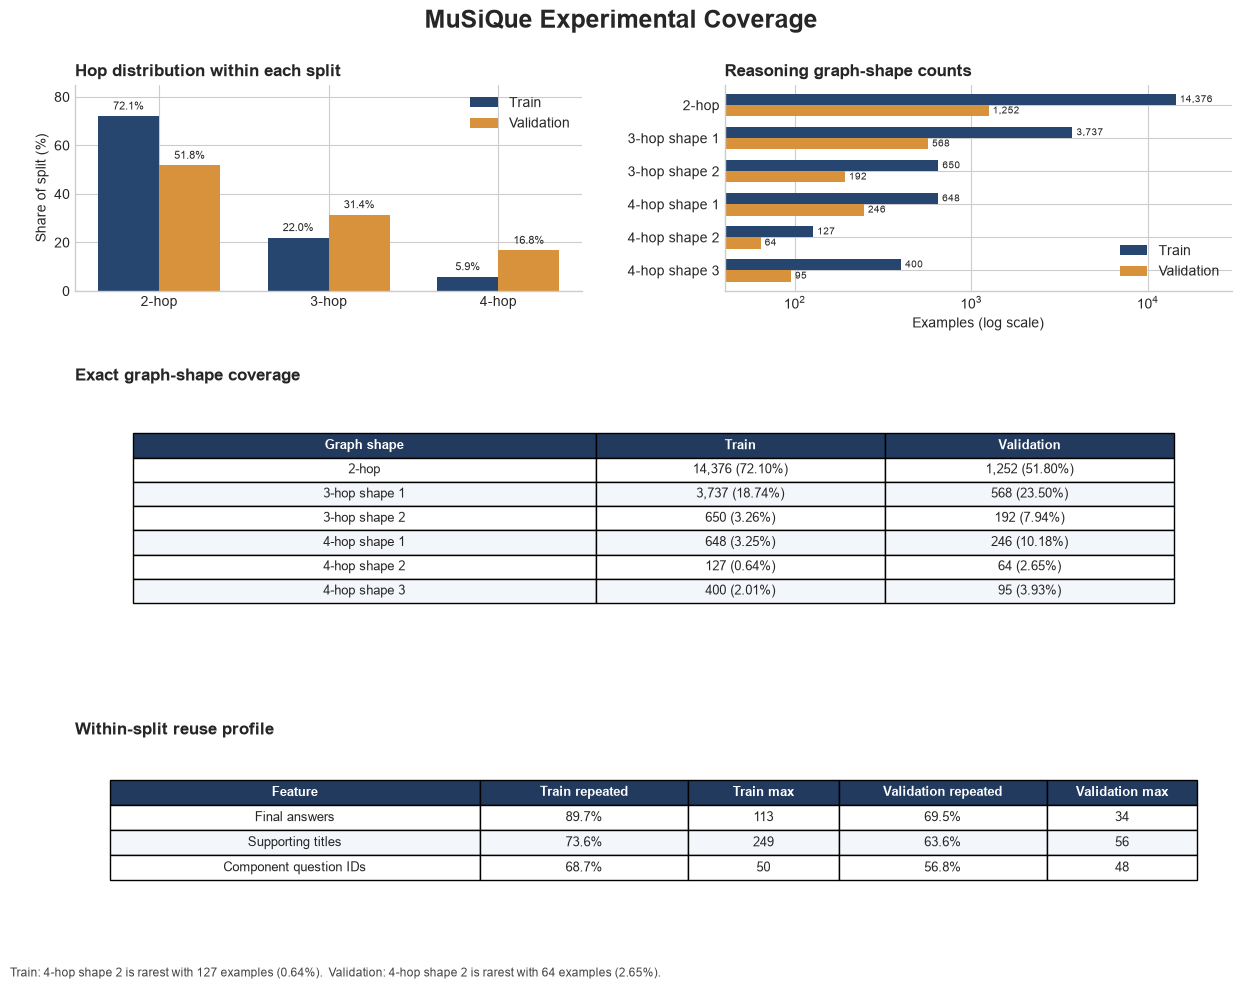

In [16]:
TRAIN_COLOR = "#27466F"
VALIDATION_COLOR = "#D8923B"
SPLIT_COLORS = {"train": TRAIN_COLOR, "validation": VALIDATION_COLOR}

fig = plt.figure(figsize=(13, 10))
fig.patch.set_facecolor("white")
grid = fig.add_gridspec(3, 2, height_ratios=[2.2, 2.7, 1.8], hspace=0.48, wspace=0.28)
hop_axis = fig.add_subplot(grid[0, 0])
graph_axis = fig.add_subplot(grid[0, 1])
coverage_axis = fig.add_subplot(grid[1, :])
reuse_axis = fig.add_subplot(grid[2, :])
fig.suptitle("MuSiQue Experimental Coverage", fontsize=18, fontweight="bold", y=0.985)

bar_width = 0.36
hop_positions = list(range(len(HOP_ORDER)))
for offset, split_name in zip((-bar_width / 2, bar_width / 2), splits):
    split_hops = hop_coverage.set_index(["split", "hop_count"]).loc[split_name]
    percentages = [split_hops.loc[hop, "split_share_pct"] for hop in HOP_ORDER]
    bars = hop_axis.bar(
        [position + offset for position in hop_positions],
        percentages,
        width=bar_width,
        color=SPLIT_COLORS[split_name],
        label=split_name.title(),
    )
    hop_axis.bar_label(bars, labels=[f"{value:.1f}%" for value in percentages], padding=3, fontsize=8)

hop_axis.set_title("Hop distribution within each split", loc="left", fontweight="bold")
hop_axis.set_xticks(hop_positions, [f"{hop}-hop" for hop in HOP_ORDER])
hop_axis.set_ylabel("Share of split (%)")
hop_axis.set_ylim(0, max(hop_coverage["split_share_pct"]) * 1.18)
hop_axis.legend(frameon=False)
hop_axis.spines[["top", "right"]].set_visible(False)

graph_positions = list(range(len(GRAPH_ORDER)))
graph_bar_height = 0.34
for offset, split_name in zip((-graph_bar_height / 2, graph_bar_height / 2), splits):
    split_graphs = graph_coverage.set_index(["split", "graph_code"]).loc[split_name]
    counts = [int(split_graphs.loc[graph_code, "count"]) for graph_code in GRAPH_ORDER]
    bars = graph_axis.barh(
        [position + offset for position in graph_positions],
        counts,
        height=graph_bar_height,
        color=SPLIT_COLORS[split_name],
        label=split_name.title(),
    )
    graph_axis.bar_label(bars, labels=[f"{count:,}" for count in counts], padding=3, fontsize=7.5)

graph_axis.set_title("Reasoning graph-shape counts", loc="left", fontweight="bold")
graph_axis.set_yticks(graph_positions, [GRAPH_LABELS[code] for code in GRAPH_ORDER])
graph_axis.invert_yaxis()
graph_axis.set_xscale("log")
graph_axis.set_xlabel("Examples (log scale)")
graph_axis.set_xlim(40, 30000)
graph_axis.legend(frameon=False, loc="lower right")
graph_axis.spines[["top", "right"]].set_visible(False)

coverage_axis.axis("off")
coverage_axis.set_title("Exact graph-shape coverage", loc="left", fontweight="bold", pad=8)
coverage_rows = []
for graph_code in GRAPH_ORDER:
    row = {"Graph shape": GRAPH_LABELS[graph_code]}
    for split_name in splits:
        result = graph_coverage.set_index(["split", "graph_code"]).loc[(split_name, graph_code)]
        row[split_name.title()] = f"{int(result['count']):,} ({result['split_share_pct']:.2f}%)"
    coverage_rows.append(row)
coverage_for_figure = pd.DataFrame(coverage_rows)
coverage_artist = coverage_axis.table(
    cellText=coverage_for_figure.values,
    colLabels=coverage_for_figure.columns,
    cellLoc="center",
    colLoc="center",
    colWidths=[0.40, 0.25, 0.25],
    loc="center",
)
coverage_artist.auto_set_font_size(False)
coverage_artist.set_fontsize(9)
coverage_artist.scale(1, 1.35)

reuse_axis.axis("off")
reuse_axis.set_title("Within-split reuse profile", loc="left", fontweight="bold", pad=8)
reuse_rows = []
for feature_name in ("Final answers", "Supporting titles", "Component question IDs"):
    row = {"Feature": feature_name}
    for split_name in splits:
        result = reuse_profile.set_index(["split", "feature"]).loc[(split_name, feature_name)]
        row[f"{split_name.title()} repeated"] = f"{result['repeated_occurrence_pct']:.1f}%"
        row[f"{split_name.title()} max"] = f"{int(result['maximum_occurrences_for_one_value']):,}"
    reuse_rows.append(row)
reuse_for_figure = pd.DataFrame(reuse_rows)
reuse_artist = reuse_axis.table(
    cellText=reuse_for_figure.values,
    colLabels=reuse_for_figure.columns,
    cellLoc="center",
    colLoc="center",
    colWidths=[0.32, 0.18, 0.13, 0.18, 0.13],
    loc="center",
)
reuse_artist.auto_set_font_size(False)
reuse_artist.set_fontsize(9)
reuse_artist.scale(1, 1.4)

for table_artist in (coverage_artist, reuse_artist):
    for (row_index, _), cell in table_artist.get_celld().items():
        if row_index == 0:
            cell.set_facecolor("#223A5E")
            cell.set_text_props(color="white", fontweight="bold")
        elif row_index % 2 == 0:
            cell.set_facecolor("#F3F6FA")

rarest_notes = []
for row in rarest_strata.itertuples(index=False):
    rarest_notes.append(
        f"{row.split.title()}: {row.graph_shape} is rarest with {row.count:,} examples ({row.split_share_pct:.2f}%)."
    )
fig.text(0.03, 0.018, "  ".join(rarest_notes), fontsize=8.5, color="#444444")
fig.subplots_adjust(left=0.08, right=0.97, top=0.91, bottom=0.08, hspace=0.60, wspace=0.28)

coverage_artifact_stem = "split_hop_graph_distribution"
coverage_artifact_paths = []
for file_format in ("pdf", "svg"):
    artifact_path = FIG_DIR / f"{coverage_artifact_stem}.{file_format}"
    fig.savefig(artifact_path, format=file_format, bbox_inches="tight")
    coverage_artifact_paths.append(artifact_path)

display(
    pd.DataFrame(
        {"saved_artifact": [str(path.relative_to(REPO_ROOT)) for path in coverage_artifact_paths]}
    )
)
plt.show()

### Interpretation for experiment design

The smallest graph-shape counts are the immediate sampling constraint. A purely proportional sample will preserve the dataset's two-hop dominance but may leave too few rare four-hop examples for stable class-conditional or activation-level comparisons. The displayed `rarest_strata` table makes that constraint explicit without selecting a sample prematurely.

High reuse rates mean that row-level counts overstate the amount of independent semantic material. When the project constructs probe-training and causal-evaluation subsets, component-question IDs and supporting titles should be considered as grouping variables. This section does not alter the official splits or prescribe a final sample size; it provides the coverage evidence needed for that later decision.

## 3. Raw solver-input size

This section measures how much source text a solver would receive if the complete MuSiQue question and all paragraph titles and texts were included. Input size affects context-window compatibility, forward-pass cost, activation volume, and the feasibility of repeated solver-critic conditions.

The current project has not fixed a solver model, tokenizer, chat template, or final prompt serialization. Consequently, this section reports exact **raw-content word counts**, not estimated model tokens. Token counts and activation-storage estimates should be added only after those choices are fixed; otherwise the result would imply precision the current design does not support.

In [17]:
RAW_WORD_PATTERN = re.compile(r"\b[\w]+(?:[-'][\w]+)*\b", flags=re.UNICODE)
SPLIT_COLORS = {"train": "#27466F", "validation": "#D8923B"}


def count_raw_words(value: object) -> int:
    return len(RAW_WORD_PATTERN.findall(str(value)))


def style_report_table(table_artist) -> None:
    for (row_index, _), cell in table_artist.get_celld().items():
        if row_index == 0:
            cell.set_facecolor("#223A5E")
            cell.set_text_props(color="white", fontweight="bold")
        elif row_index % 2 == 0:
            cell.set_facecolor("#F3F6FA")


def save_figure_pair(figure, artifact_stem: str) -> list[Path]:
    paths = []
    for file_format in ("pdf", "svg"):
        path = FIG_DIR / f"{artifact_stem}.{file_format}"
        figure.savefig(path, format=file_format, bbox_inches="tight")
        paths.append(path)
    return paths


input_size_records = []
for split_name, frame in splits.items():
    for row in frame.itertuples(index=False):
        question_words = count_raw_words(row.question)
        supporting_words = 0
        distractor_words = 0
        for paragraph in row.paragraphs:
            paragraph_words = count_raw_words(paragraph["title"]) + count_raw_words(
                paragraph["paragraph_text"]
            )
            if paragraph["is_supporting"] is True:
                supporting_words += paragraph_words
            else:
                distractor_words += paragraph_words
        input_size_records.append(
            {
                "split": split_name,
                "hop_count": len(row.question_decomposition),
                "question_words": question_words,
                "supporting_words": supporting_words,
                "distractor_words": distractor_words,
                "raw_input_words": question_words + supporting_words + distractor_words,
            }
        )

input_size_profile = pd.DataFrame(input_size_records)
input_quantile_records = []
for (split_name, hop_count), group in input_size_profile.groupby(["split", "hop_count"]):
    values = group["raw_input_words"]
    input_quantile_records.append(
        {
            "split": split_name,
            "hop_count": hop_count,
            "examples": len(group),
            "median_words": values.median(),
            "p90_words": values.quantile(0.90),
            "p99_words": values.quantile(0.99),
            "maximum_words": values.max(),
        }
    )
input_size_quantiles = pd.DataFrame(input_quantile_records)
input_component_summary = (
    input_size_profile.groupby("split")[
        ["question_words", "supporting_words", "distractor_words", "raw_input_words"]
    ]
    .mean()
    .round(1)
)

display(input_size_quantiles.round(0).astype({"hop_count": int, "examples": int}))
display(input_component_summary)

,split,hop_count,examples,median_words,p90_words,p99_words,maximum_words
0,train,2,14376,1592.0,2124.0,2650.0,3228
1,train,3,4387,1700.0,2215.0,2671.0,3100
2,train,4,1175,1831.0,2318.0,2667.0,2960
3,validation,2,1252,1644.0,2195.0,2702.0,3293
4,validation,3,760,1751.0,2473.0,2903.0,3041
5,validation,4,405,1760.0,2191.0,2592.0,2820


,question_words,supporting_words,distractor_words,raw_input_words
split,,,,
train,16.0,205.6,1434.2,1655.7
validation,18.1,243.1,1466.7,1727.9


### Saved input-size artifact

The report shows the full raw-input distribution, compares hop strata, separates question/support/distractor contributions, and provides exact distribution quantiles. Paragraph titles are counted because a normal solver prompt would preserve them. Prompt instructions, role markers, and generated solver or critic text are excluded because they do not yet exist.

The paired artifact uses the stem `solver_input_word_length_profile`.

,saved_artifact
0,Code/notebooks/figs/solver_input_word_length_p...
1,Code/notebooks/figs/solver_input_word_length_p...


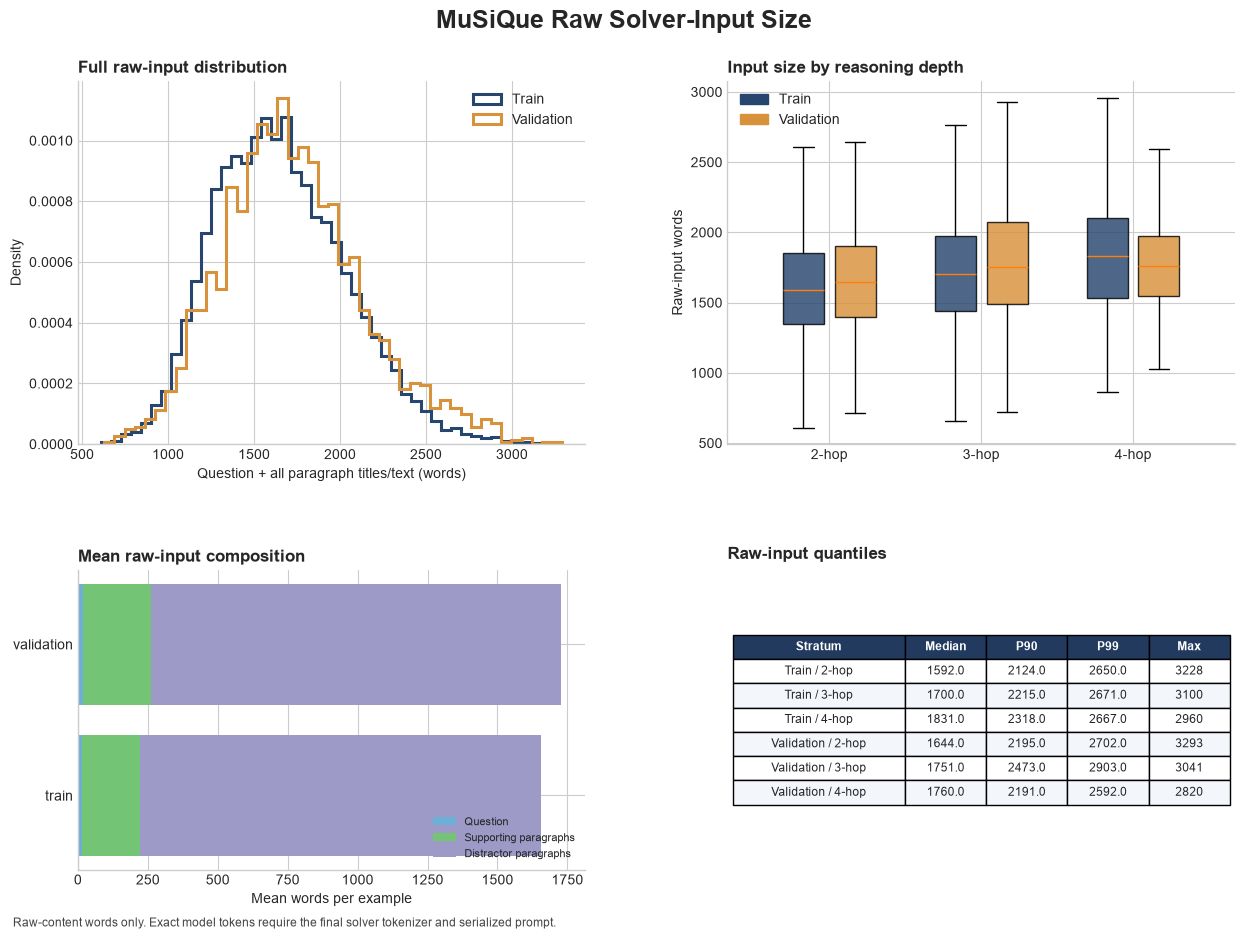

In [18]:
fig = plt.figure(figsize=(13, 9.5))
fig.patch.set_facecolor("white")
grid = fig.add_gridspec(2, 2, height_ratios=[2.0, 1.65], hspace=0.38, wspace=0.28)
distribution_axis = fig.add_subplot(grid[0, 0])
hop_axis = fig.add_subplot(grid[0, 1])
component_axis = fig.add_subplot(grid[1, 0])
quantile_axis = fig.add_subplot(grid[1, 1])
fig.suptitle("MuSiQue Raw Solver-Input Size", fontsize=18, fontweight="bold", y=0.985)

for split_name in splits:
    distribution_axis.hist(
        input_size_profile.loc[input_size_profile["split"] == split_name, "raw_input_words"],
        bins=45,
        density=True,
        histtype="step",
        linewidth=2.2,
        color=SPLIT_COLORS[split_name],
        label=split_name.title(),
    )
distribution_axis.set_title("Full raw-input distribution", loc="left", fontweight="bold")
distribution_axis.set_xlabel("Question + all paragraph titles/text (words)")
distribution_axis.set_ylabel("Density")
distribution_axis.legend(frameon=False)
distribution_axis.spines[["top", "right"]].set_visible(False)

box_data = []
box_positions = []
box_colors = []
for hop_index, hop_count in enumerate(HOP_ORDER, start=1):
    for offset, split_name in zip((-0.17, 0.17), splits):
        box_data.append(
            input_size_profile.loc[
                (input_size_profile["split"] == split_name)
                & (input_size_profile["hop_count"] == hop_count),
                "raw_input_words",
            ]
        )
        box_positions.append(hop_index + offset)
        box_colors.append(SPLIT_COLORS[split_name])
boxes = hop_axis.boxplot(
    box_data, positions=box_positions, widths=0.27, patch_artist=True, showfliers=False
)
for box, color in zip(boxes["boxes"], box_colors):
    box.set_facecolor(color)
    box.set_alpha(0.82)
hop_axis.set_title("Input size by reasoning depth", loc="left", fontweight="bold")
hop_axis.set_xticks(range(1, len(HOP_ORDER) + 1), [f"{hop}-hop" for hop in HOP_ORDER])
hop_axis.set_ylabel("Raw-input words")
hop_axis.spines[["top", "right"]].set_visible(False)
hop_axis.legend(
    handles=[
        plt.Rectangle((0, 0), 1, 1, color=SPLIT_COLORS[name], label=name.title()) for name in splits
    ],
    frameon=False,
)

component_axis.set_title("Mean raw-input composition", loc="left", fontweight="bold")
component_columns = ["question_words", "supporting_words", "distractor_words"]
component_labels = ["Question", "Supporting paragraphs", "Distractor paragraphs"]
component_colors = ["#6BAED6", "#74C476", "#9E9AC8"]
left_values = [0.0] * len(splits)
for column, label, color in zip(component_columns, component_labels, component_colors):
    values = [input_component_summary.loc[name, column] for name in splits]
    component_axis.barh(list(splits), values, left=left_values, label=label, color=color)
    left_values = [left + value for left, value in zip(left_values, values)]
component_axis.set_xlabel("Mean words per example")
component_axis.legend(frameon=False, fontsize=8, loc="lower right")
component_axis.spines[["top", "right"]].set_visible(False)

quantile_axis.axis("off")
quantile_axis.set_title("Raw-input quantiles", loc="left", fontweight="bold", pad=8)
quantiles_for_figure = input_size_quantiles.copy()
quantiles_for_figure["Stratum"] = (
    quantiles_for_figure["split"].str.title()
    + " / "
    + quantiles_for_figure["hop_count"].astype(str)
    + "-hop"
)
quantiles_for_figure = quantiles_for_figure[
    ["Stratum", "median_words", "p90_words", "p99_words", "maximum_words"]
].round(0)
quantiles_for_figure.columns = ["Stratum", "Median", "P90", "P99", "Max"]
quantile_artist = quantile_axis.table(
    cellText=quantiles_for_figure.values,
    colLabels=quantiles_for_figure.columns,
    cellLoc="center",
    colLoc="center",
    colWidths=[0.34, 0.16, 0.16, 0.16, 0.16],
    loc="center",
)
quantile_artist.auto_set_font_size(False)
quantile_artist.set_fontsize(8.5)
quantile_artist.scale(1, 1.35)
style_report_table(quantile_artist)

fig.text(
    0.03, 0.02,
    "Raw-content words only. Exact model tokens require the final solver tokenizer and serialized prompt.",
    fontsize=8.5, color="#444444",
)
fig.subplots_adjust(left=0.08, right=0.97, top=0.91, bottom=0.08)
input_size_artifact_paths = save_figure_pair(fig, "solver_input_word_length_profile")
display(pd.DataFrame({"saved_artifact": [str(path.relative_to(REPO_ROOT)) for path in input_size_artifact_paths]}))
plt.show()

### Interpretation for the solver-critic pipeline

The distractor paragraphs dominate the input volume, so the eventual activation budget will be driven more by context construction than by question length or the number of supporting steps. Differences across hop counts remain relevant because deeper questions require more supporting text and may produce longer reasoning traces.

Before activation collection, rerun this analysis with the exact solver tokenizer and complete prompt, then multiply token counts by the chosen activation sites, hidden width, bytes per stored value, solver attempts, and feedback conditions. That model-dependent calculation is deliberately not guessed here.

## 4. Supporting versus distractor context

MuSiQue places a small set of supporting paragraphs among a much larger set of distractors. This section checks whether support and distractor contexts differ in count, length, position, or simple lexical overlap with the question. It also measures where gold final and intermediate answers occur. These properties can create shortcuts or ambiguity that affect solver behavior independently of critic feedback.

### Measurement details

Paragraph word counts include titles and body text. Question-paragraph overlap is token-set Jaccard similarity: intersection size divided by union size after Unicode-aware lowercasing and word extraction. This is a transparent lexical diagnostic, not a semantic similarity score.

Answer occurrence uses normalized whole-token phrase matching in paragraph bodies. The final-answer search accepts the canonical answer or any provided alias. An intermediate answer is marked as ambiguous when its normalized text occurs in more than one paragraph. This identifies textual multiplicity, not necessarily annotation error: difficult distractors may intentionally mention the same entity.

In [19]:
MATCH_TOKEN_PATTERN = re.compile(r"\w+", flags=re.UNICODE)


def token_set(value: object) -> set[str]:
    return set(MATCH_TOKEN_PATTERN.findall(str(value).casefold()))


def normalize_for_occurrence(value: object) -> str:
    return " ".join(MATCH_TOKEN_PATTERN.findall(str(value).casefold()))


def normalized_phrase_is_present(normalized_text: str, normalized_phrase: str) -> bool:
    return bool(normalized_phrase) and f" {normalized_phrase} " in f" {normalized_text} "


context_records = []
paragraph_records = []
for split_name, frame in splits.items():
    for row in frame.itertuples(index=False):
        hop_count = len(row.question_decomposition)
        question_tokens = token_set(row.question)
        normalized_paragraph_texts = []
        supporting_indexes = set()

        for paragraph in row.paragraphs:
            combined_text = f"{paragraph['title']} {paragraph['paragraph_text']}"
            paragraph_tokens = token_set(combined_text)
            token_union = question_tokens | paragraph_tokens
            is_supporting = paragraph["is_supporting"] is True
            if is_supporting:
                supporting_indexes.add(paragraph["idx"])
            paragraph_records.append(
                {
                    "split": split_name,
                    "hop_count": hop_count,
                    "role": "Supporting" if is_supporting else "Distractor",
                    "position": paragraph["idx"],
                    "paragraph_words": count_raw_words(combined_text),
                    "question_jaccard": (
                        len(question_tokens & paragraph_tokens) / len(token_union) if token_union else 0.0
                    ),
                }
            )
            normalized_paragraph_texts.append(normalize_for_occurrence(paragraph["paragraph_text"]))

        final_phrases = {
            normalize_for_occurrence(candidate)
            for candidate in (row.answer, *row.answer_aliases)
            if normalize_for_occurrence(candidate)
        }
        final_occurrence_indexes = {
            index
            for index, paragraph_text in enumerate(normalized_paragraph_texts)
            if any(
                normalized_phrase_is_present(paragraph_text, phrase) for phrase in final_phrases
            )
        }
        intermediate_is_ambiguous = any(
            sum(
                normalized_phrase_is_present(
                    paragraph_text, normalize_for_occurrence(step["answer"])
                )
                for paragraph_text in normalized_paragraph_texts
            )
            > 1
            for step in row.question_decomposition[:-1]
        )
        context_records.append(
            {
                "split": split_name,
                "hop_count": hop_count,
                "supporting_paragraphs": len(supporting_indexes),
                "distractor_paragraphs": len(row.paragraphs) - len(supporting_indexes),
                "final_answer_in_support": bool(final_occurrence_indexes & supporting_indexes),
                "final_answer_in_distractor": bool(final_occurrence_indexes - supporting_indexes),
                "final_answer_not_found": not final_occurrence_indexes,
                "ambiguous_intermediate_answer": intermediate_is_ambiguous,
            }
        )

context_profile = pd.DataFrame(context_records)
paragraph_profile = pd.DataFrame(paragraph_records)
context_count_summary = (
    context_profile.groupby(["split", "hop_count"])[
        ["supporting_paragraphs", "distractor_paragraphs"]
    ]
    .mean()
    .reset_index()
)
paragraph_role_summary = (
    paragraph_profile.groupby(["split", "role"])
    .agg(
        paragraphs=("paragraph_words", "size"),
        median_words=("paragraph_words", "median"),
        p90_words=("paragraph_words", lambda values: values.quantile(0.90)),
        median_question_jaccard=("question_jaccard", "median"),
    )
    .reset_index()
)
answer_occurrence_summary = (
    context_profile.groupby("split")[
        [
            "final_answer_in_support",
            "final_answer_in_distractor",
            "final_answer_not_found",
            "ambiguous_intermediate_answer",
        ]
    ]
    .mean()
    .mul(100)
)

display(context_count_summary.round(2))
display(paragraph_role_summary.round(3))
display(answer_occurrence_summary.round(2))

,split,hop_count,supporting_paragraphs,distractor_paragraphs
0,train,2,2.0,18.00
1,train,3,3.0,17.00
2,train,4,4.0,16.00
3,validation,2,2.0,18.00
4,validation,3,3.0,16.97
5,validation,4,4.0,16.00


,split,role,paragraphs,median_words,p90_words,median_question_jaccard
0,train,Distractor,352111,70.0,143.0,0.082
1,train,Supporting,46613,77.0,161.0,0.086
2,validation,Distractor,41911,74.0,153.0,0.085
3,validation,Supporting,6404,80.0,167.0,0.086


,final_answer_in_support,final_answer_in_distractor,final_answer_not_found,ambiguous_intermediate_answer
split,,,,
train,99.39,16.47,0.32,92.36
validation,99.83,13.69,0.17,94.46


### Saved context artifact

The report combines average support/distractor counts, paragraph-length comparisons, supporting-paragraph positions, and answer-occurrence diagnostics. Position percentages are normalized across all supporting paragraphs within a split, so a flat line would indicate roughly uniform placement.

The paired artifact uses the stem `support_distractor_context_profile`.

,saved_artifact
0,Code/notebooks/figs/support_distractor_context...
1,Code/notebooks/figs/support_distractor_context...


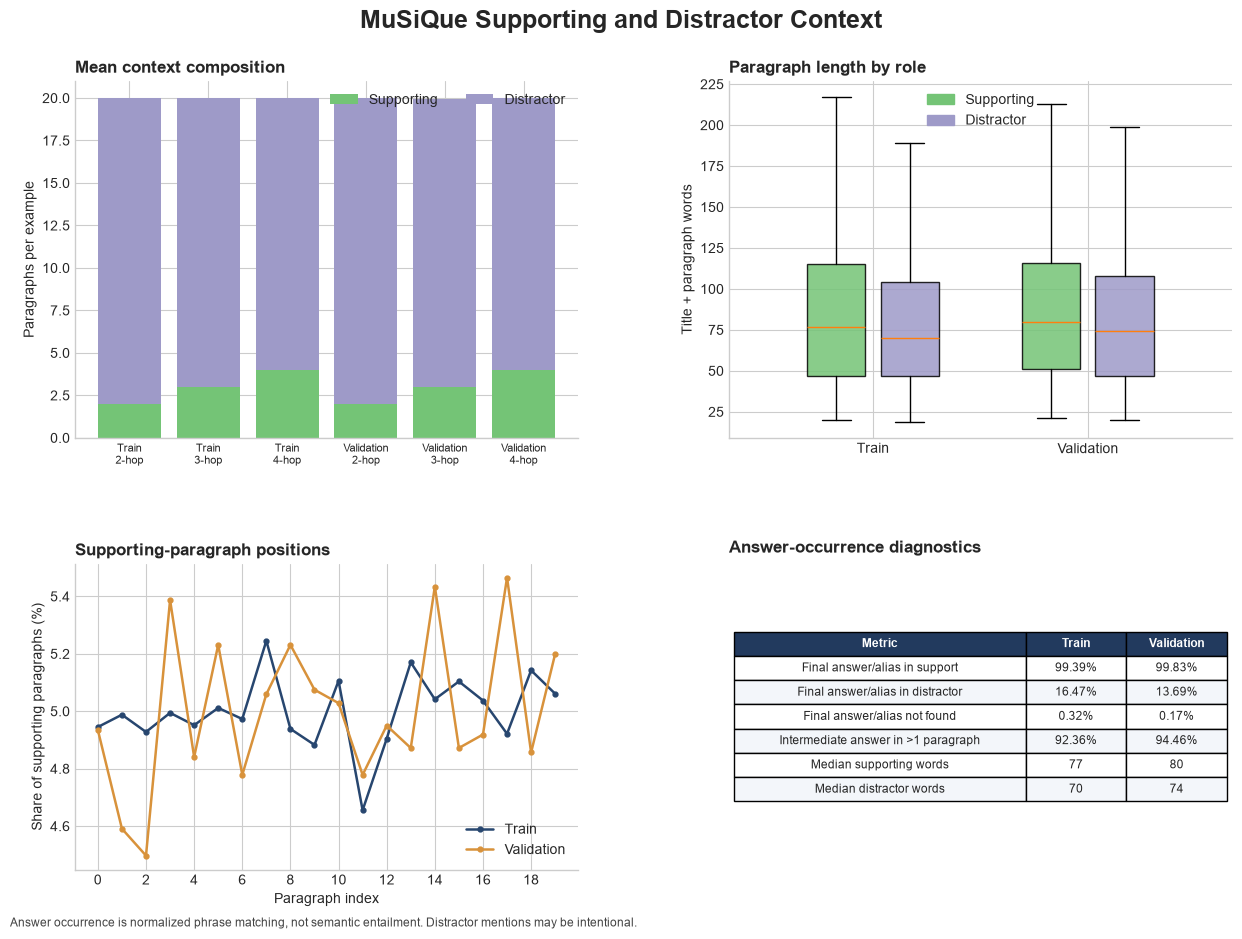

In [20]:
fig = plt.figure(figsize=(13, 9.5))
fig.patch.set_facecolor("white")
grid = fig.add_gridspec(2, 2, height_ratios=[2.1, 1.8], hspace=0.38, wspace=0.30)
count_axis = fig.add_subplot(grid[0, 0])
length_axis = fig.add_subplot(grid[0, 1])
position_axis = fig.add_subplot(grid[1, 0])
occurrence_axis = fig.add_subplot(grid[1, 1])
fig.suptitle("MuSiQue Supporting and Distractor Context", fontsize=18, fontweight="bold", y=0.985)

stratum_labels = []
support_values = []
distractor_values = []
for split_name in splits:
    for hop_count in HOP_ORDER:
        result = context_count_summary.set_index(["split", "hop_count"]).loc[(split_name, hop_count)]
        stratum_labels.append(f"{split_name.title()}\n{hop_count}-hop")
        support_values.append(result["supporting_paragraphs"])
        distractor_values.append(result["distractor_paragraphs"])
positions = list(range(len(stratum_labels)))
count_axis.bar(positions, support_values, color="#74C476", label="Supporting")
count_axis.bar(
    positions, distractor_values, bottom=support_values, color="#9E9AC8", label="Distractor"
)
count_axis.set_title("Mean context composition", loc="left", fontweight="bold")
count_axis.set_xticks(positions, stratum_labels, fontsize=8)
count_axis.set_ylabel("Paragraphs per example")
count_axis.legend(frameon=False, ncol=2)
count_axis.spines[["top", "right"]].set_visible(False)

length_groups = []
length_positions = []
length_colors = []
length_labels = []
for split_index, split_name in enumerate(splits, start=1):
    for offset, role, color in ((-0.17, "Supporting", "#74C476"), (0.17, "Distractor", "#9E9AC8")):
        length_groups.append(
            paragraph_profile.loc[
                (paragraph_profile["split"] == split_name) & (paragraph_profile["role"] == role),
                "paragraph_words",
            ]
        )
        length_positions.append(split_index + offset)
        length_colors.append(color)
    length_labels.append(split_name.title())
length_boxes = length_axis.boxplot(
    length_groups, positions=length_positions, widths=0.27, patch_artist=True, showfliers=False
)
for box, color in zip(length_boxes["boxes"], length_colors):
    box.set_facecolor(color)
    box.set_alpha(0.85)
length_axis.set_title("Paragraph length by role", loc="left", fontweight="bold")
length_axis.set_xticks(range(1, len(splits) + 1), length_labels)
length_axis.set_ylabel("Title + paragraph words")
length_axis.legend(
    handles=[
        plt.Rectangle((0, 0), 1, 1, color="#74C476", label="Supporting"),
        plt.Rectangle((0, 0), 1, 1, color="#9E9AC8", label="Distractor"),
    ],
    frameon=False,
)
length_axis.spines[["top", "right"]].set_visible(False)

support_positions = paragraph_profile.loc[paragraph_profile["role"] == "Supporting"]
for split_name in splits:
    counts = (
        support_positions.loc[support_positions["split"] == split_name, "position"]
        .value_counts(normalize=True)
        .reindex(range(20), fill_value=0)
        .mul(100)
    )
    position_axis.plot(
        counts.index, counts.values, marker="o", markersize=3.5, linewidth=1.8,
        color=SPLIT_COLORS[split_name], label=split_name.title(),
    )
position_axis.set_title("Supporting-paragraph positions", loc="left", fontweight="bold")
position_axis.set_xlabel("Paragraph index")
position_axis.set_ylabel("Share of supporting paragraphs (%)")
position_axis.set_xticks(range(0, 20, 2))
position_axis.legend(frameon=False)
position_axis.spines[["top", "right"]].set_visible(False)

occurrence_axis.axis("off")
occurrence_axis.set_title("Answer-occurrence diagnostics", loc="left", fontweight="bold", pad=8)
occurrence_metrics = {
    "Final answer/alias in support": "final_answer_in_support",
    "Final answer/alias in distractor": "final_answer_in_distractor",
    "Final answer/alias not found": "final_answer_not_found",
    "Intermediate answer in >1 paragraph": "ambiguous_intermediate_answer",
}
occurrence_rows = []
for label, column in occurrence_metrics.items():
    occurrence_rows.append(
        {"Metric": label, **{name.title(): f"{answer_occurrence_summary.loc[name, column]:.2f}%" for name in splits}}
    )
for role in ("Supporting", "Distractor"):
    occurrence_rows.append(
        {
            "Metric": f"Median {role.lower()} words",
            **{
                name.title(): f"{paragraph_role_summary.set_index(['split', 'role']).loc[(name, role), 'median_words']:.0f}"
                for name in splits
            },
        }
    )
occurrence_for_figure = pd.DataFrame(occurrence_rows)
occurrence_artist = occurrence_axis.table(
    cellText=occurrence_for_figure.values, colLabels=occurrence_for_figure.columns,
    cellLoc="center", colLoc="center", colWidths=[0.58, 0.20, 0.20], loc="center",
)
occurrence_artist.auto_set_font_size(False)
occurrence_artist.set_fontsize(8.5)
occurrence_artist.scale(1, 1.35)
style_report_table(occurrence_artist)

fig.text(
    0.03, 0.02,
    "Answer occurrence is normalized phrase matching, not semantic entailment. Distractor mentions may be intentional.",
    fontsize=8.5, color="#444444",
)
fig.subplots_adjust(left=0.08, right=0.97, top=0.91, bottom=0.08)
context_artifact_paths = save_figure_pair(fig, "support_distractor_context_profile")
display(pd.DataFrame({"saved_artifact": [str(path.relative_to(REPO_ROOT)) for path in context_artifact_paths]}))
plt.show()

### Interpretation for feedback experiments

Support position and lexical similarity should not be treated as explanations of model behavior, but they are useful shortcut diagnostics. Final-answer appearances in distractors and repeated intermediate entities can make an answer look locally plausible without establishing the intended connected reasoning chain.

When pilot solver results become available, accuracy and critic-helpfulness rates should be stratified by these context properties. That will help distinguish feedback uptake from changes caused by context ambiguity or easily recognized evidence.

## 5. Answer forms, aliases, and scoring risk

Correctness labels will determine whether critic feedback is classified as helpful or harmful. This section profiles answer length, aliases, repeated answers, and text-normalization sensitivity so formatting differences do not silently become experimental labels.

### Measurement details

Answer categories here describe **surface form**, not semantic entity type. They are: yes/no, date/year, numeric, short text of one to three words, and longer text. Identifying people, locations, and organizations would require a separately validated entity classifier and is not inferred from capitalization.

The scoring diagnostic applies common SQuAD-style text normalization: Unicode-aware lowercasing, punctuation removal, removal of the English articles `a`, `an`, and `the`, and whitespace collapse. This does not declare the project's final scorer. It quantifies how often raw exact matching would be sensitive to harmless formatting and how often MuSiQue aliases add genuinely distinct normalized targets.

In [21]:
import unicodedata

MONTH_NAMES = {
    "january", "february", "march", "april", "may", "june",
    "july", "august", "september", "october", "november", "december",
}
ARTICLE_PATTERN = re.compile(r"\b(?:a|an|the)\b", flags=re.IGNORECASE)
YEAR_PATTERN = re.compile(
    r"(?:c\.\s*)?\d{3,4}(?:\s*[-–]\s*\d{2,4})?(?:\s*(?:bc|bce|ad|ce))?",
    flags=re.IGNORECASE,
)
NUMERIC_PATTERN = re.compile(
    r"[+-]?[\d,]+(?:\.\d+)?(?:\s*[-–]\s*[\d,]+(?:\.\d+)?)?(?:%|\s+percent)?",
    flags=re.IGNORECASE,
)
SURFACE_CATEGORY_ORDER = (
    "Yes/no", "Date/year", "Numeric", "Short text (1-3 words)", "Long text (4+ words)"
)


def scoring_normalize(value: object) -> str:
    lowered = str(value).casefold()
    without_punctuation = "".join(
        character for character in lowered if not unicodedata.category(character).startswith("P")
    )
    without_articles = ARTICLE_PATTERN.sub(" ", without_punctuation)
    return " ".join(without_articles.split())


def answer_surface_category(value: object) -> str:
    text = str(value).strip()
    normalized_tokens = normalize_for_occurrence(text).split()
    if normalize_for_occurrence(text) in {"yes", "no"}:
        return "Yes/no"
    if YEAR_PATTERN.fullmatch(text) or any(token in MONTH_NAMES for token in normalized_tokens):
        return "Date/year"
    if NUMERIC_PATTERN.fullmatch(text):
        return "Numeric"
    if len(normalized_tokens) <= 3:
        return "Short text (1-3 words)"
    return "Long text (4+ words)"


answer_records = []
for split_name, frame in splits.items():
    normalized_canonical_counts = frame["answer"].map(scoring_normalize).value_counts()
    for row in frame.itertuples(index=False):
        answer = str(row.answer)
        normalized_answer = scoring_normalize(answer)
        normalized_aliases = {scoring_normalize(alias) for alias in row.answer_aliases}
        normalized_aliases.discard("")
        answer_records.append(
            {
                "split": split_name,
                "answer": answer,
                "normalized_answer": normalized_answer,
                "answer_words": count_raw_words(answer),
                "answer_characters": len(answer),
                "alias_count": len(row.answer_aliases),
                "surface_category": answer_surface_category(answer),
                "has_aliases": bool(row.answer_aliases),
                "aliases_add_distinct_target": bool(normalized_aliases - {normalized_answer}),
                "contains_punctuation": any(
                    unicodedata.category(character).startswith("P") for character in answer
                ),
                "contains_non_ascii": any(ord(character) > 127 for character in answer),
                "normalization_changes_answer": normalized_answer != answer.strip(),
                "normalized_answer_is_reused": normalized_canonical_counts[normalized_answer] > 1,
            }
        )

answer_profile = pd.DataFrame(answer_records)
answer_length_summary = (
    answer_profile.groupby("split")["answer_words"]
    .agg(
        examples="size", median_words="median",
        p90_words=lambda values: values.quantile(0.90),
        p99_words=lambda values: values.quantile(0.99), maximum_words="max",
    )
)
answer_category_summary = (
    answer_profile.groupby("split")["surface_category"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("share_pct")
    .reset_index()
)
answer_risk_columns = [
    "has_aliases", "aliases_add_distinct_target", "contains_punctuation",
    "contains_non_ascii", "normalization_changes_answer", "normalized_answer_is_reused",
]
answer_risk_summary = answer_profile.groupby("split")[answer_risk_columns].mean().mul(100)
alias_buckets = pd.cut(
    answer_profile["alias_count"], bins=[-1, 0, 1, 2, 3, float("inf")],
    labels=["0", "1", "2", "3", "4+"],
)
answer_profile = answer_profile.assign(alias_bucket=alias_buckets)
alias_summary = (
    answer_profile.groupby("split", observed=True)["alias_bucket"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("share_pct")
    .reset_index()
)
top_answers = {
    split_name: (
        answer_profile.loc[answer_profile["split"] == split_name, "normalized_answer"]
        .value_counts()
        .head(5)
    )
    for split_name in splits
}

display(answer_length_summary.round(1))
display(answer_category_summary.assign(share_pct=lambda table: table["share_pct"].round(2)))
display(answer_risk_summary.round(2))

,examples,median_words,p90_words,p99_words,maximum_words
split,,,,,
train,19938,2.0,4.0,10.0,14
validation,2417,2.0,5.0,11.0,15


,split,surface_category,share_pct
0,train,Short text (1-3 words),58.83
1,train,Date/year,22.37
2,train,Long text (4+ words),13.21
3,train,Numeric,5.59
4,validation,Short text (1-3 words),57.39
5,validation,Long text (4+ words),19.82
6,validation,Date/year,19.40
7,validation,Numeric,3.39


,has_aliases,aliases_add_distinct_target,contains_punctuation,contains_non_ascii,normalization_changes_answer,normalized_answer_is_reused
split,,,,,,
train,25.41,23.34,20.21,2.02,79.84,98.11
validation,28.13,24.82,18.95,1.86,83.78,85.31


### Saved answer artifact

The report shows answer-length and alias distributions, surface-form composition, common answers, and scoring-sensitivity rates. The answer histogram is limited to the combined 99th-percentile word length so the dominant distribution remains readable; the quantile summary displayed above retains the full tail.

The paired artifact uses the stem `answer_type_and_scoring_profile`.

,saved_artifact
0,Code/notebooks/figs/answer_type_and_scoring_pr...
1,Code/notebooks/figs/answer_type_and_scoring_pr...


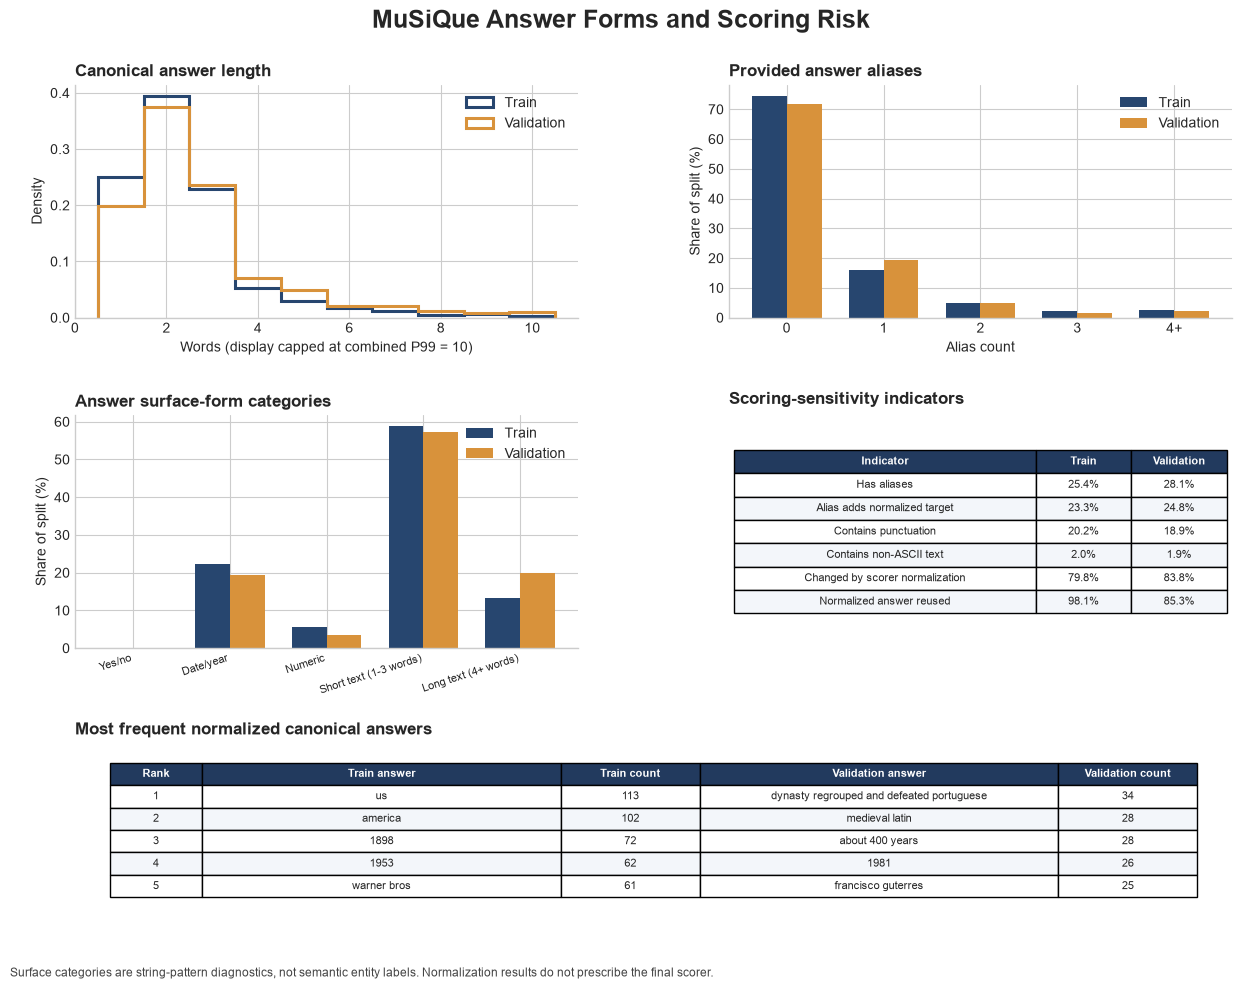

In [22]:
fig = plt.figure(figsize=(13, 10))
fig.patch.set_facecolor("white")
grid = fig.add_gridspec(3, 2, height_ratios=[2.0, 2.0, 1.45], hspace=0.46, wspace=0.30)
length_axis = fig.add_subplot(grid[0, 0])
alias_axis = fig.add_subplot(grid[0, 1])
category_axis = fig.add_subplot(grid[1, 0])
risk_axis = fig.add_subplot(grid[1, 1])
common_axis = fig.add_subplot(grid[2, :])
fig.suptitle("MuSiQue Answer Forms and Scoring Risk", fontsize=18, fontweight="bold", y=0.985)

answer_word_limit = max(5, int(answer_profile["answer_words"].quantile(0.99)))
histogram_bins = [value - 0.5 for value in range(1, answer_word_limit + 2)]
for split_name in splits:
    values = answer_profile.loc[
        (answer_profile["split"] == split_name)
        & (answer_profile["answer_words"] <= answer_word_limit),
        "answer_words",
    ]
    length_axis.hist(
        values, bins=histogram_bins, density=True, histtype="step", linewidth=2.2,
        color=SPLIT_COLORS[split_name], label=split_name.title(),
    )
length_axis.set_title("Canonical answer length", loc="left", fontweight="bold")
length_axis.set_xlabel(f"Words (display capped at combined P99 = {answer_word_limit})")
length_axis.set_ylabel("Density")
length_axis.legend(frameon=False)
length_axis.spines[["top", "right"]].set_visible(False)

alias_categories = ["0", "1", "2", "3", "4+"]
alias_positions = list(range(len(alias_categories)))
bar_width = 0.36
for offset, split_name in zip((-bar_width / 2, bar_width / 2), splits):
    split_aliases = alias_summary.set_index(["split", "alias_bucket"])
    percentages = [
        split_aliases.loc[(split_name, category), "share_pct"]
        if (split_name, category) in split_aliases.index else 0
        for category in alias_categories
    ]
    alias_axis.bar(
        [position + offset for position in alias_positions], percentages, width=bar_width,
        color=SPLIT_COLORS[split_name], label=split_name.title(),
    )
alias_axis.set_title("Provided answer aliases", loc="left", fontweight="bold")
alias_axis.set_xticks(alias_positions, alias_categories)
alias_axis.set_xlabel("Alias count")
alias_axis.set_ylabel("Share of split (%)")
alias_axis.legend(frameon=False)
alias_axis.spines[["top", "right"]].set_visible(False)

category_positions = list(range(len(SURFACE_CATEGORY_ORDER)))
for offset, split_name in zip((-bar_width / 2, bar_width / 2), splits):
    split_categories = answer_category_summary.set_index(["split", "surface_category"])
    percentages = [
        split_categories.loc[(split_name, category), "share_pct"]
        if (split_name, category) in split_categories.index else 0
        for category in SURFACE_CATEGORY_ORDER
    ]
    category_axis.bar(
        [position + offset for position in category_positions], percentages, width=bar_width,
        color=SPLIT_COLORS[split_name], label=split_name.title(),
    )
category_axis.set_title("Answer surface-form categories", loc="left", fontweight="bold")
category_axis.set_xticks(category_positions, SURFACE_CATEGORY_ORDER, rotation=18, ha="right", fontsize=8)
category_axis.set_ylabel("Share of split (%)")
category_axis.legend(frameon=False)
category_axis.spines[["top", "right"]].set_visible(False)

risk_axis.axis("off")
risk_axis.set_title("Scoring-sensitivity indicators", loc="left", fontweight="bold", pad=8)
risk_labels = {
    "has_aliases": "Has aliases",
    "aliases_add_distinct_target": "Alias adds normalized target",
    "contains_punctuation": "Contains punctuation",
    "contains_non_ascii": "Contains non-ASCII text",
    "normalization_changes_answer": "Changed by scorer normalization",
    "normalized_answer_is_reused": "Normalized answer reused",
}
risk_rows = [
    {
        "Indicator": label,
        **{split_name.title(): f"{answer_risk_summary.loc[split_name, column]:.1f}%" for split_name in splits},
    }
    for column, label in risk_labels.items()
]
risk_for_figure = pd.DataFrame(risk_rows)
risk_artist = risk_axis.table(
    cellText=risk_for_figure.values, colLabels=risk_for_figure.columns,
    cellLoc="center", colLoc="center", colWidths=[0.60, 0.19, 0.19], loc="center",
)
risk_artist.auto_set_font_size(False)
risk_artist.set_fontsize(8.2)
risk_artist.scale(1, 1.30)
style_report_table(risk_artist)

common_axis.axis("off")
common_axis.set_title("Most frequent normalized canonical answers", loc="left", fontweight="bold", pad=8)
common_rows = []
for rank in range(5):
    row = {"Rank": rank + 1}
    for split_name in splits:
        answer = top_answers[split_name].index[rank]
        count = int(top_answers[split_name].iloc[rank])
        row[f"{split_name.title()} answer"] = answer
        row[f"{split_name.title()} count"] = count
    common_rows.append(row)
common_for_figure = pd.DataFrame(common_rows)
common_artist = common_axis.table(
    cellText=common_for_figure.values, colLabels=common_for_figure.columns,
    cellLoc="center", colLoc="center",
    colWidths=[0.08, 0.31, 0.12, 0.31, 0.12], loc="center",
)
common_artist.auto_set_font_size(False)
common_artist.set_fontsize(8.2)
common_artist.scale(1, 1.25)
style_report_table(common_artist)

fig.text(
    0.03, 0.018,
    "Surface categories are string-pattern diagnostics, not semantic entity labels. Normalization results do not prescribe the final scorer.",
    fontsize=8.5, color="#444444",
)
fig.subplots_adjust(left=0.08, right=0.97, top=0.91, bottom=0.08)
answer_artifact_paths = save_figure_pair(fig, "answer_type_and_scoring_profile")
display(pd.DataFrame({"saved_artifact": [str(path.relative_to(REPO_ROOT)) for path in answer_artifact_paths]}))
plt.show()

### Interpretation for ground-truth labels

Raw exact string equality is not sufficient for labeling solver or critic correctness when aliases, punctuation, articles, casing, numeric formats, or Unicode variants are present. The final evaluation function should accept canonical answers and aliases under one documented normalization policy, while retaining raw model text for auditability.

Repeated short answers also make accidental matches more likely. During pilot labeling, inspect disagreements between exact match, normalized exact match, token F1, and any semantic judge rather than silently resolving them with a single permissive metric.